In [1]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe
from pyearthtools.data.time import Petdt
from pyearthtools.pipeline.operations.xarray.join import GeospatialTimeSeriesMerge
import site_archive_nci

import shap

In [7]:
model = xgb.XGBRegressor()
# model.load_model("/scratch/er8/cd3022/xgb_models/test_model.json")
model.load_model("/scratch/er8/cd3022/xgb_models/radiance_hour_model.json")

In [3]:
# data = pd.read_parquet('/scratch/er8/cd3022/xgb_datasets/syd_gridpoint_2024-01.parquet')
data = pd.read_parquet('/scratch/er8/cd3022/xgb_datasets/syd_radiances_2025-01-01+5.parquet')

In [4]:
# Add last hour of observations to training data
for n in range(1, 7):
    data.loc[:,[f'channel_0003_scaled_radiance_t-{n}']] = (
        data['channel_0003_scaled_radiance'].groupby(['latitude', 'longitude']).shift(n)
    )
    data.loc[:,[f'channel_0004_scaled_radiance_t-{n}']] = (
        data['channel_0004_scaled_radiance'].groupby(['latitude', 'longitude']).shift(n)
    )
    data.loc[:,[f'channel_0008_brightness_temperature_t-{n}']] = (
        data['channel_0008_brightness_temperature'].groupby(['latitude', 'longitude']).shift(n)
    )
    data.loc[:,[f'channel_0011_brightness_temperature_t-{n}']] = (
        data['channel_0011_brightness_temperature'].groupby(['latitude', 'longitude']).shift(n)
    )
    data.loc[:,[f'channel_0013_brightness_temperature_t-{n}']] = (
        data['channel_0013_brightness_temperature'].groupby(['latitude', 'longitude']).shift(n)
    )
    data.loc[:,[f'channel_0015_brightness_temperature_t-{n}']] = (
        data['channel_0015_brightness_temperature'].groupby(['latitude', 'longitude']).shift(n)
    )

data = data.dropna()

X = data.drop(columns=['surface_global_irradiance'])
for n in range(1, 11):
    X = X.drop(columns=[f'surface_global_irradiance_t{n}'])

y = data['surface_global_irradiance_t6']

In [9]:
importance = model.feature_importances_

feat_importance = pd.Series(importance, index=X.columns)
feat_importance = feat_importance.sort_values(ascending=False)

print(feat_importance)

channel_0003_scaled_radiance               0.184549
solar_elevation                            0.116623
channel_0011_brightness_temperature        0.114822
channel_0004_scaled_radiance_t-6           0.084999
channel_0003_scaled_radiance_t-2           0.076943
channel_0013_brightness_temperature        0.058690
channel_0011_brightness_temperature_t-6    0.047393
channel_0003_scaled_radiance_t-6           0.021993
channel_0003_scaled_radiance_t-1           0.021746
channel_0015_brightness_temperature        0.019304
channel_0008_brightness_temperature_t-6    0.017379
channel_0003_scaled_radiance_t-3           0.015351
channel_0013_brightness_temperature_t-6    0.015267
channel_0004_scaled_radiance_t-5           0.015239
channel_0003_scaled_radiance_t-4           0.013596
channel_0004_scaled_radiance_t-4           0.013030
channel_0008_brightness_temperature        0.012280
channel_0008_brightness_temperature_t-4    0.011252
channel_0015_brightness_temperature_t-3    0.010509
channel_0015

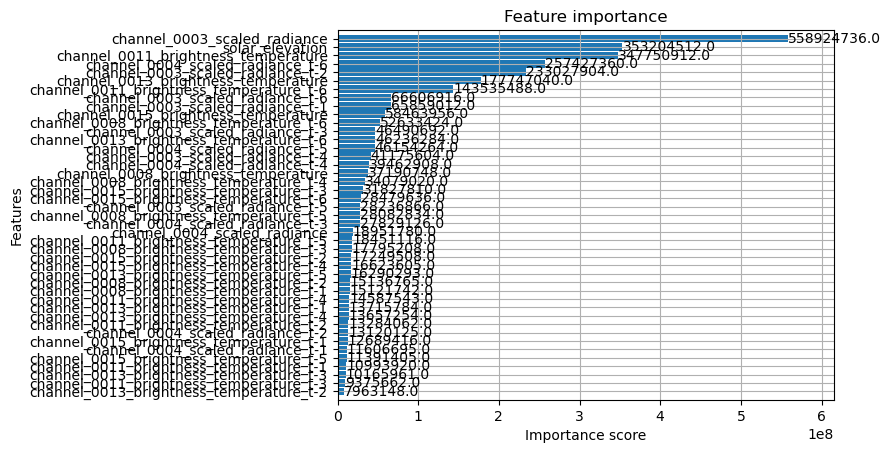

In [10]:
_ = xgb.plot_importance(model, height=0.9, importance_type="gain")

In [11]:
explainer = shap.Explainer(model)

idx = np.random.choice(len(X), size=20000, replace=False)
X_sample = X.iloc[idx]

shap_values = explainer(X_sample)

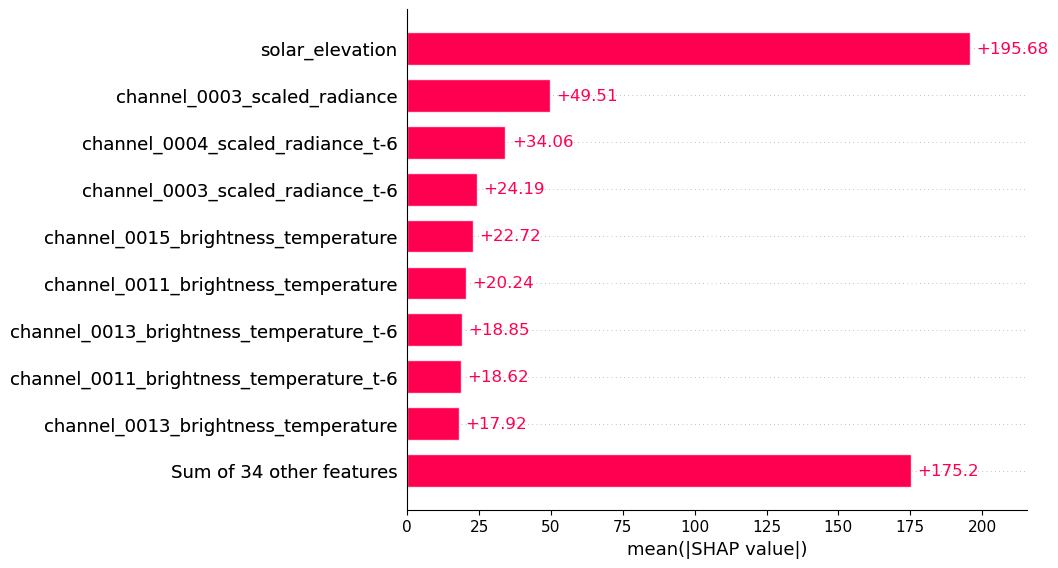

In [12]:
shap.plots.bar(shap_values)

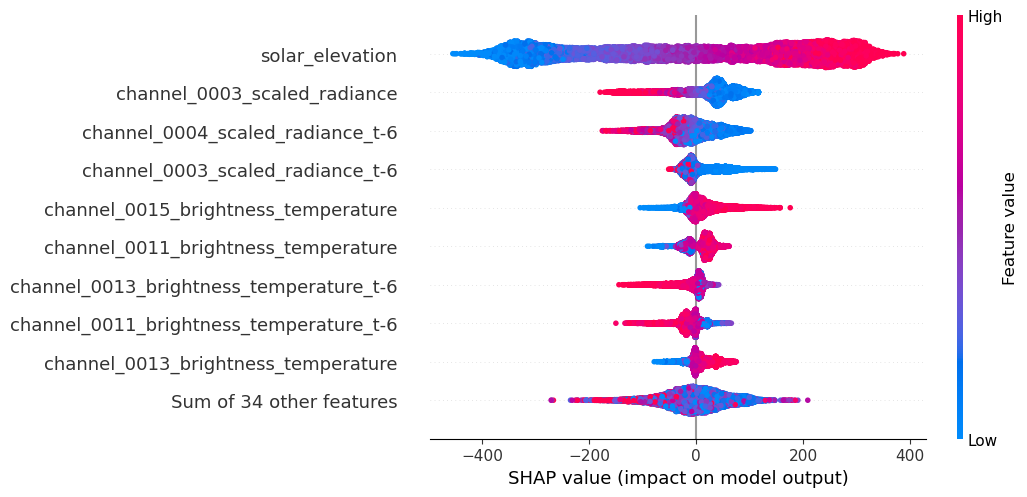

In [13]:
shap.plots.beeswarm(shap_values)